In [46]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.colors as colors

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [47]:
cd C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\04.kraken2.out\bracken\species

C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\04.kraken2.out\bracken\species


In [48]:
import pandas as pd

df_tax = pd.read_csv("species_merged_num.txt", sep='\t',
#                     skiprows=1,
                     index_col="name")
df_tax["Total"] = df_tax.sum(axis=1)
df_tax = df_tax.sort_values("Total", ascending=False)

meta = pd.read_csv("C:/Users/tr432/Downloads/filter_GutLungAxis_Control/maaslin3_RUN45_Metadata_GutLungAxis.txt", sep='\t')  ## csv일땐 sep='\t' 지워도 됨

print(df_tax.head(3))
print(meta.head(3))

                          C01-2w   C02-2w   C03-2w   C09-2w   C10-2w   C11-2w  \
name                                                                            
Enterobacter hormaechei     3186     2848     7966     4049     3441     3593   
Klebsiella aerogenes         346      375      471      188      216      164   
Phocaeicola vulgatus     2633274  3113587  3601543  3929328  1621151  2314694   

                          V01-2w   V02-2w   V03-2w  V04-2w    V05-2w  \
name                                                                   
Enterobacter hormaechei    24684    16249    10169     946  15692289   
Klebsiella aerogenes     9172196  7526808  4378271  358778      1275   
Phocaeicola vulgatus          64       22       27       0       100   

                           V06-2w   V07-2w   V08-2w   V10-2w     Total  
name                                                                    
Enterobacter hormaechei  12862885  7788144  3286403  9145613  48852465  
Klebsiella aer

In [49]:
mapping = dict(zip(meta["#SampleID"].astype(str), meta["Group"].astype(str)))

df_tax2 = df_tax.copy()
df_tax2.columns = [mapping.get(c, None) for c in df_tax.columns[0:]]

df_tax2 = df_tax2.loc[:, [c for c in df_tax2.columns if c is not None]]

grouped = df_tax2.set_index(df_tax2.index).T.groupby(level=0).mean().T

grouped["Total"] = df_tax["Total"]

print(grouped.shape)
grouped

(12341, 3)


,Control,VNAM,Total
name,,,
Enterobacter hormaechei,4.180500e+03,5.425265e+06,48852465
Klebsiella aerogenes,2.933333e+02,2.382216e+06,21441707
Phocaeicola vulgatus,2.868930e+06,4.833333e+01,17214012
Ligilactobacillus murinus,1.150789e+06,2.475493e+05,9132678
Escherichia coli,1.219650e+04,3.778676e+05,3473987
...,...,...,...
Robertmurraya mangrovi,1.666667e+00,0.000000e+00,10
Pyrodictium abyssi,1.666667e+00,0.000000e+00,10
Natronococcus occultus,1.666667e+00,0.000000e+00,10


In [50]:
for col in grouped.columns:
    print(col, sum(grouped[col]))

Control 9214609.333333334
VNAM 9858665.0
Total 144015641


In [51]:
grouped.reset_index(inplace=True)
grouped

#grouped.to_csv("rel_gg2_genus_table_grouped.tsv", sep='\t', index=False)

,name,Control,VNAM,Total
0,Enterobacter hormaechei,4.180500e+03,5.425265e+06,48852465
1,Klebsiella aerogenes,2.933333e+02,2.382216e+06,21441707
2,Phocaeicola vulgatus,2.868930e+06,4.833333e+01,17214012
3,Ligilactobacillus murinus,1.150789e+06,2.475493e+05,9132678
4,Escherichia coli,1.219650e+04,3.778676e+05,3473987
...,...,...,...,...
12336,Robertmurraya mangrovi,1.666667e+00,0.000000e+00,10
12337,Pyrodictium abyssi,1.666667e+00,0.000000e+00,10
12338,Natronococcus occultus,1.666667e+00,0.000000e+00,10
12339,Halorientalis pallida,1.666667e+00,0.000000e+00,10


In [52]:
df = grouped.copy()
df.rename(columns={'name': 'Species'}, inplace=True)
df

,Species,Control,VNAM,Total
0,Enterobacter hormaechei,4.180500e+03,5.425265e+06,48852465
1,Klebsiella aerogenes,2.933333e+02,2.382216e+06,21441707
2,Phocaeicola vulgatus,2.868930e+06,4.833333e+01,17214012
3,Ligilactobacillus murinus,1.150789e+06,2.475493e+05,9132678
4,Escherichia coli,1.219650e+04,3.778676e+05,3473987
...,...,...,...,...
12336,Robertmurraya mangrovi,1.666667e+00,0.000000e+00,10
12337,Pyrodictium abyssi,1.666667e+00,0.000000e+00,10
12338,Natronococcus occultus,1.666667e+00,0.000000e+00,10
12339,Halorientalis pallida,1.666667e+00,0.000000e+00,10


In [53]:
df2 = df[
    df['Species'].notna() &
    ~df['Species'].str.strip().isin(['', '_'])
]

df2.head(25)

,Species,Control,VNAM,Total
0,Enterobacter hormaechei,4.180500e+03,5.425265e+06,48852465
1,Klebsiella aerogenes,2.933333e+02,2.382216e+06,21441707
2,Phocaeicola vulgatus,2.868930e+06,4.833333e+01,17214012
3,Ligilactobacillus murinus,1.150789e+06,2.475493e+05,9132678
4,Escherichia coli,1.219650e+04,3.778676e+05,3473987
5,Klebsiella pneumoniae,4.638667e+03,2.474287e+05,2254690
6,Klebsiella variicola,5.401667e+02,1.931422e+05,1741521
7,Akkermansia muciniphila,2.869875e+05,1.555556e+00,1721939
8,Enterobacter sp. JH25,0.000000e+00,1.709231e+05,1538308
9,Parabacteroides goldsteinii,2.159953e+05,4.881111e+02,1300365


In [58]:
## Species Level - Relative Abundance로 변환 후 정렬


df3 = df2.copy()

num_cols = df3.columns[1:]
df3[num_cols] = df3[num_cols].div(df3[num_cols].sum(axis=0), axis=1)  #Edit: 이 줄을 주석처리하면 Read Counts 나타낼 수 있음


# 2-1. 상위 n개 기준: 각 taxon 의 전체 합
df3['rel_feature_sum'] = df3[num_cols].sum(axis=1)

# 2-2. Others 로 보낼 문자열 패턴 지정
banned_prefix = ['Homo sapiens']  #Edit: 바로 위 셀의 head(25) 결과 보고 직접 판단

# Genus 기준으로 패턴 포함 여부
mask_banned = df3['Species'].str.startswith(tuple(banned_prefix))

# 2-2. 상위 n개 (banned 는 제외하고 뽑기)
df_allowed = df3.loc[~mask_banned]
df_allowed = df_allowed.sort_values('Total', ascending=False)
top_idx = df_allowed.index[:30]  #Edit: 상위 몇개만 가져올지 선택

# 최종적으로 Others 로 갈 행
mask_top = df3.index.isin(top_idx)
mask_others = ~mask_top #| mask_banned   # top n 밖이거나, banned 인 것들

# 2-3. 상위 n개만 남기기
df_top = df3.loc[~mask_others].copy()
df_top = df_top.sort_values('Total', ascending=False)
print(df_top['Control'].sum())
print(df_top['VNAM'].sum())

# 2-4. Others 행 만들기 (나머지 합)
others_vals = df3.loc[mask_others, num_cols].sum()
others_row = {'Species': 'Others'}
for c in num_cols:
    others_row[c] = others_vals[c]

df_final = pd.concat([df_top, pd.DataFrame([others_row])],
                     ignore_index=True)

# rel_feature_sum 컬럼은 필요 없으면 제거
#df_final = df_final.drop(columns=['rel_feature_sum'])
print(df_final['Control'].sum())
print(df_final['VNAM'].sum())

#df3.head(25)
#df_allowed.head(15)
#df_top
df_final

0.6793696046726957
0.9464084527559149
0.9999999999999998
1.0000000000000002


,Species,Control,VNAM,Total,rel_feature_sum
0,Enterobacter hormaechei,0.000454,5.503042e-01,0.339216,0.889974
1,Klebsiella aerogenes,0.000032,2.416368e-01,0.148885,0.390553
2,Phocaeicola vulgatus,0.311346,4.902625e-06,0.119529,0.430879
3,Ligilactobacillus murinus,0.124887,2.510982e-02,0.063414,0.213412
4,Escherichia coli,0.001324,3.832847e-02,0.024122,0.063774
5,Klebsiella pneumoniae,0.000503,2.509758e-02,0.015656,0.041257
6,Klebsiella variicola,0.000059,1.959111e-02,0.012093,0.031742
7,Akkermansia muciniphila,0.031145,1.577856e-07,0.011957,0.043102
8,Enterobacter sp. JH25,0.000000,1.733735e-02,0.010682,0.028019
9,Parabacteroides goldsteinii,0.023441,4.951087e-05,0.009029,0.032519


In [59]:
df_final_species = df_final.drop(columns=['rel_feature_sum'])

#df_final_species.to_csv("df_final_genus.tsv", sep='\t', index=False)

print(df_final_species.columns)
df_final_species

Index(['Species', 'Control', 'VNAM', 'Total'], dtype='object')


,Species,Control,VNAM,Total
0,Enterobacter hormaechei,0.000454,5.503042e-01,0.339216
1,Klebsiella aerogenes,0.000032,2.416368e-01,0.148885
2,Phocaeicola vulgatus,0.311346,4.902625e-06,0.119529
3,Ligilactobacillus murinus,0.124887,2.510982e-02,0.063414
4,Escherichia coli,0.001324,3.832847e-02,0.024122
5,Klebsiella pneumoniae,0.000503,2.509758e-02,0.015656
6,Klebsiella variicola,0.000059,1.959111e-02,0.012093
7,Akkermansia muciniphila,0.031145,1.577856e-07,0.011957
8,Enterobacter sp. JH25,0.000000,1.733735e-02,0.010682
9,Parabacteroides goldsteinii,0.023441,4.951087e-05,0.009029


In [60]:
cols = ['Species'] + df_final_species.columns[1:3].tolist()
df_barplot = df_final_species[cols]
df_barplot = df_barplot.set_index(df_barplot.columns[0])
df_barplot = df_barplot.transpose()

df_barplot

Species,Enterobacter hormaechei,Klebsiella aerogenes,Phocaeicola vulgatus,Ligilactobacillus murinus,Escherichia coli,Klebsiella pneumoniae,Klebsiella variicola,Akkermansia muciniphila,Enterobacter sp. JH25,Parabacteroides goldsteinii,...,Blautia producta,Mediterraneibacter gnavus,Dysosmobacter welbionis,[Clostridium] scindens,Bifidobacterium pseudolongum,Dysosmobacter sp. Phy,Flavonifractor plautii,Enterocloster bolteae,Clostridium sp. 10cd*,Others
Control,0.000454,0.000032,0.311346,0.124887,0.001324,0.000503,0.000059,3.114484e-02,0.000000,0.023441,...,0.008739,0.007311,0.007305,0.007256,0.006488,0.006174,0.006097,0.005927,0.005765,0.320630
VNAM,0.550304,0.241637,0.000005,0.025110,0.038328,0.025098,0.019591,1.577856e-07,0.017337,0.000050,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.053592


In [61]:
# 색 조합 1 (무지개 - 하늘색/청록색/연두색/노란색/주황색 .... 총 30색)
cmap1 = colors.ListedColormap(['#b6e1f3','#1699a8','#aad356','#f9c908','#f25844','#c44065','#d9c097','#fff9d6','#a6e0b9','#00ada7',
                               '#183c59','#735a99','#ff4062','#ff9c98','#facdaa','#c8c9a8','#80b09b','#c5c7c7','#007792','#011519',
                               '#8c296b','#897800','#da8e00','#e05500','#920000','#4c5760','#93a8ac','#bab7d3','#a59e8c','#66635b'])

# 색 조합 2 (파스텔 - 연분홍색/연주황색/겨자색/옥색/하늘색 .... 총 30색)
cmap2 = colors.ListedColormap(['#fbd0c0','#f3b988','#e1c784','#87dfbb','#61eaec','#4ac2e6','#b3a3c5','#5ebbb6','#88e0bb','#a1ca8e',
                               '#e6efab','#cce8d6','#fff2cc','#fbc6d6','#fbc6d6','#ee9bb9','#f8cbad','#ffe699','#c5e0b4','#7bc19c',
                               '#6ba599','#3abce4','#1b8c95','#975f8c','#a76d5d','#d0a292','#d872a0','#cab4cc','#d9d9d9','#7f7f7f'])

# 색 조합 3 (사계절 - 짙은청색/민트색/옅은녹색/아이보리색/살구색/주황색 .... 총 30색)
cmap3 = colors.ListedColormap(['#12263a','#06bcc1','#c5d8d1','#f4edea','#f4d1ae','#f28f3b','#c8553d','#985277','#784863','#847e89',
                               '#afbfc0','#cce3de','#a7c957','#6a994e','#386641','#677423','#bbc191','#e8e0d0','#b47b54','#845b3c',
                               '#bfa4a4','#e6c0c3','#ffa29b','#fb6376','#b44b2e','#d87b0a','#eeba0b','#f4e409','#ecf49e','#7f7f7f'])

GutLungAxis = colors.ListedColormap(["#C96E7B","#4A7EA8","#D9A45A","#4F9A7A","#E0B5A0",
                                     "#6A87B5","#C98FCA","#5E8E91","#C3B86D","#4E9260",
                                     "#D48D6F","#5E6E8A","#B0778A","#6E7F73","#BFA27C",
                                     "#7B87A0","#A97F65","#8E8F9A","#CBBFB2","#F3EEE7",
                                     "#DDDDDD"])

GutLungAxis_vivid = colors.ListedColormap(["#EF404A","#00A7EB","#FFD400","#80B463","#F2728C",
                                           "#556C99","#9E7EB9","#4EB8B9","#F79552","#4F9472",
                                           "#F9C0C7","#FFCC4E","#D5E05B","#81D3EB","#B0DFDB",
                                           "#BBB8DC","#A7A9AC","#C69AB0","#E3DED0","#F3EEE7",
                                           "#DDDDDD"])

wine_soft_21 = colors.ListedColormap(["#8C2744","#B33C4F","#CC5664","#E06C74","#EB8586",
                                      "#F29B94","#F5B3A9","#F8C9BC","#9A3E63","#BF6783",
                                      "#D9889A","#EFA3B8","#C55A70","#E06E93","#D89A5C",
                                      "#E3B66D","#B88257","#A07166","#D4B4AF","#F6EBE4",
                                      "#DDDDDD"])

darkpurple_axis_rosegold_21 = colors.ListedColormap(["#5A255D","#742C6E","#8A2F7C","#A13788","#B55297",
                                                     "#C66AA7","#D282B8","#B5738F","#C5859F","#D79CAF",
                                                     "#E4B6C3","#8C6BC5","#A080D6","#B39BE3","#C8B3EE",
                                                     "#C88A5A","#E0A96D","#F2C48C","#E7D4F2","#F2E7FA",
                                                     "#DDDDDD"])

prussian_blue = colors.ListedColormap(["#5F89A3","#8FB6C9","#6F9EB5","#A9C7D6","#6A8FA5",
                                       "#3F6F8E","#2F5F82","#1E4E74","#41586E","#9A9A98",
                                       "#7F8A93","#6E7680","#5C6168","#4C5259","#3A3F45",
                                       "#2B2F34","#2B5E8F","#3C6F98","#2E5F86","#254F73",
                                       "#1E4466","#183A58","#142F49","#0E253B","#D2C4B5",
                                       "#B89E84","#9E7C69","#845D54","#6A413F","#4F2A2C",
                                       "#DDDDDD"])

nordic_forest_30 = colors.ListedColormap(["#2E5F8C","#6F9CC4","#3E88C4","#2F6FAE","#6F7FA0",
                                          "#BFC2D4","#9FA4B8","#7F83A0","#4F5370","#3F445C",
                                          "#7FAEC4","#5F8FA8","#3F6F86","#2F7FA5","#2FA3B5",
                                          "#4FB6C4","#5FAFC0","#3F8F9A","#5FA8A5","#7FBFB8",
                                          "#C3B8D4","#5A66C4","#9FA4D0","#6F7FB5","#4F5A9A",
                                          "#6FC6C5","#5FB7AE","#6FAFA5","#8FC3B8","#A9D6D1",
                                          "#DDDDDD"])

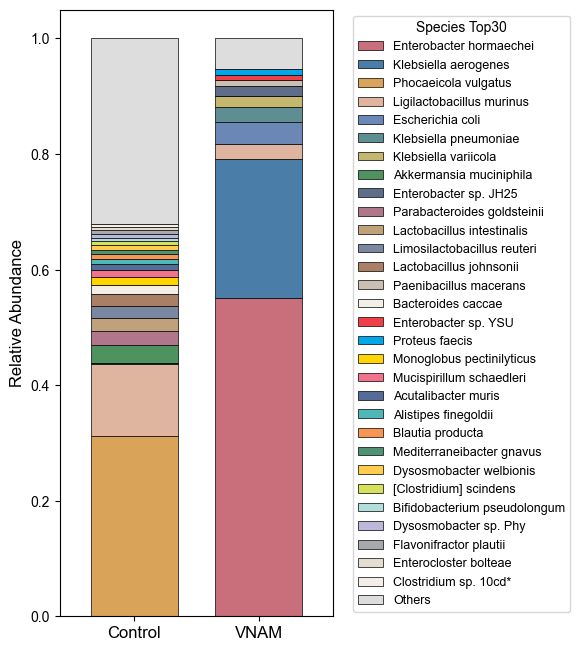

In [65]:
## species Level - Top 30

combined_colors = GutLungAxis.colors + GutLungAxis_vivid.colors
combined_cmap = colors.ListedColormap(combined_colors)

df_barplot.plot(kind='bar', stacked=True,figsize=(6, 7), colormap=combined_cmap, edgecolor='k', linewidth=0.5, width=0.7)  ## Pastel1은 9개 색 제공 -> 그 이상은 색깔 돌려막기
plt.xticks(ticks=range(len(df_barplot.index)), labels=['Control', 'VNAM'], rotation=0, fontsize=12)  #Edit: plot에 표시될 이름으로 labels 지정
plt.yticks(fontsize=10)
plt.xlabel('')
plt.ylabel('Relative Abundance', fontsize=12)  #Edit
plt.title('')
plt.legend(title='Species Top30', bbox_to_anchor=(1.05, 1.0), fontsize=9)  #Edit: legend 위치에 맞춰서 조정
plt.tight_layout()
plt.savefig('species_rel_top30_diffColor.png', dpi=500, bbox_inches='tight')
plt.show()

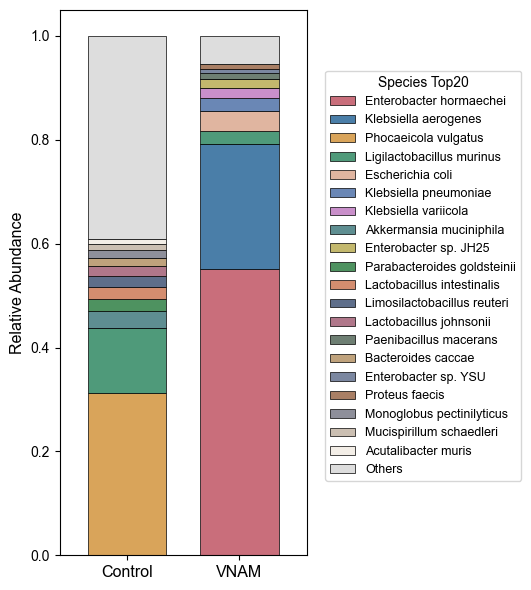

In [41]:
## species Level - Top 20

df_barplot.plot(kind='bar', stacked=True,figsize=(5.5, 6), colormap=GutLungAxis, edgecolor='k', linewidth=0.5, width=0.7)  ## Pastel1은 9개 색 제공 -> 그 이상은 색깔 돌려막기
plt.xticks(ticks=range(len(df_barplot.index)), labels=['Control', 'VNAM'], rotation=0, fontsize=11.5)  #Edit: plot에 표시될 이름으로 labels 지정
plt.yticks(fontsize=10)
plt.xlabel('')
plt.ylabel('Relative Abundance', fontsize=11.5)  #Edit
plt.title('')
plt.legend(title='Species Top20', bbox_to_anchor=(1.05, 0.9), fontsize=9)  #Edit: legend 위치에 맞춰서 조정
plt.tight_layout()
plt.savefig('species_rel_top20_diffColor.png', dpi=500, bbox_inches='tight')
plt.show()